<h3>🍫 Chocolate Sales Analysis & Shipment Prediction<h3></h3>
Predicting chocolate shipment volume and uncovering the key business factors driving sales performance across products, countries, and sales channels.


### 📌 Problem Statement

Chocolate sales are influenced by multiple business factors, including product type, pricing, discounts, marketing campaigns, sales channels, and seasonal demand patterns.

This project analyzes order-level chocolate sales data from 2022–2023 to understand sales behavior, identify important business drivers, and build machine learning models capable of predicting shipment volume.


### 🎯 Objectives

* Perform data cleaning and preprocessing on real-world sales data.
* Handle missing values, duplicate records, mixed date formats, and outliers.
* Explore sales trends across products, countries, and channels.
* Analyze the impact of discounts and marketing spend on shipment volume.
* Build and evaluate machine learning models to predict **Boxes_Shipped**.
* Identify the most influential features affecting chocolate sales.


### 📊 Dataset Overview

The dataset contains chocolate sales transactions across multiple countries and sales channels.

#### Key Information

* 📅 Time Period: January 2022 – December 2023
* 🌍 Countries: 5
* 👨‍💼 Sales Representatives: 25
* 🍫 Product Lines: 12
* 🛒 Sales Channels: Retail, Online, Wholesale
* 📦 Target Variable: Boxes_Shipped


### 🔍 Business Questions

* Can we accurately predict shipment volume from order-level features?
* Which factors drive higher sales: discounts or marketing spend?
* Which sales channel generates the highest shipment volume?
* How do seasonal events affect chocolate demand?
* Which products perform best across different countries?


### 🧹 Data Cleaning Tasks

The dataset contains several real-world data quality issues:

✔ Missing Values

✔ Duplicate Records

✔ Mixed Date Formats

✔ Outliers in Sales Metrics

✔ Feature Engineering for Date Variables


### 🤖 Machine Learning Approach

The primary prediction target is:

#### 🎯 Boxes_Shipped

Models considered:

* Linear Regression
* Random Forest Regressor
* XGBoost Regressor
* LightGBM Regressor

Performance will be evaluated using:

* MAE (Mean Absolute Error)
* RMSE (Root Mean Squared Error)
* R² Score


### 💡 Please Suggest Improvements

Feedback on data cleaning, exploratory analysis, feature engineering, visualization design, and model performance is highly appreciated.


### 📝 Note

This project focuses on applying data analysis and machine learning techniques to a realistic sales dataset containing common business data challenges.

Thank you for visiting this notebook! 🚀

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arjunmehta1992/chocolate-sales-in-20222023/Chocolate_Sales.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

Dataset Link :- https://www.kaggle.com/datasets/arjunmehta1992/chocolate-sales-in-20222023

# 1. Understanding Data

In [3]:
data = pd.read_csv("/kaggle/input/datasets/arjunmehta1992/chocolate-sales-in-20222023/Chocolate_Sales.csv")
df = pd.DataFrame(data)
df.head()

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,2022-12-11,3.5,13.72,202.03,71,912.31
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,2023-03-14,9.4,3.30,55.18,84,245.91
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,2023-12-21,4.9,18.21,60.65,35,583.7
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,2023-12-18,15.0,2.66,52.00,92,211.27
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,2023-08-18,4.4,2.75,187.44,214,549.69


In [4]:
df.shape

(200000, 11)

In [5]:
print('Columns contains Null values : ')
df.isnull().sum()[df.isnull().sum() > 0]

Columns contains Null values : 


Order_Date         437
Discount_Pct       489
Price_per_Box      457
Marketing_Spend    461
dtype: int64

In [6]:
print("Total Duplicates : ",df.duplicated().sum())

Total Duplicates :  0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  object 
 1   Product          200000 non-null  object 
 2   Country          200000 non-null  object 
 3   Channel          200000 non-null  object 
 4   Salesperson      200000 non-null  object 
 5   Order_Date       199563 non-null  object 
 6   Discount_Pct     199511 non-null  float64
 7   Price_per_Box    199543 non-null  float64
 8   Marketing_Spend  199539 non-null  float64
 9   Boxes_Shipped    200000 non-null  int64  
 10  Amount           200000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 16.8+ MB


Above shows that column 'Amount" which must be numeric(int/float) is object

In [8]:
spelling_check = ["Product","Country","Channel","Salesperson"]
for col in spelling_check:
    print(f"Column Name {col} : ")
    print(df[col].unique())
    print("Total Unique values contains are : ",df[col].nunique())
    print()

Column Name Product : 
['Truffle Gift Box' '85% Dark Bar' '70% Dark Bar' 'Hazelnut Milk Bar'
 'Almond Crunch Bar' 'Mixed Assortment Box' 'Milk Classic Bar'
 'Pralines Gift Box' 'Salted Caramel Bar' 'White Choco Bar'
 'Mint Dark Bar' 'Choco Coins Bag']
Total Unique values contains are :  12

Column Name Country : 
['Australia' 'Japan' 'Germany' 'Brazil' 'India']
Total Unique values contains are :  5

Column Name Channel : 
['Retail' 'Online' 'Wholesale']
Total Unique values contains are :  3

Column Name Salesperson : 
['Arjun Mehta' 'Hannah Müller' 'Yuki Sato' 'Lucas Walker' 'Ananya Gupta'
 'Rohan Patel' 'Priya Sharma' 'Carlos Mendez' 'Camila Santos'
 'Emily Clarke' 'Beatriz Souza' 'James Carter' 'Felix Becker'
 'Rafael Oliveira' 'Michael Johnson' 'Sora Watanabe' 'Isabella Rossi'
 'Olivia Bennett' 'Gabriel Silva' 'Haruto Tanaka' 'Lukas Schmidt'
 'Sophie Dubois' 'Daniel Weber' 'Henry Foster' 'Laura Hoffmann']
Total Unique values contains are :  25



In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Discount_Pct,199511.0,13.107457,6.374477,0.00,8.30,12.60,17.50,38.300000
Price_per_Box,199543.0,5.911507,4.954976,2.04,2.95,3.28,4.57,21.650000
Marketing_Spend,199539.0,95.450141,66.243760,4.30,52.27,78.85,118.71,798.222443
Boxes_Shipped,200000.0,139.584105,118.665393,-1642.00,67.00,113.00,180.00,3811.000000


Total number of Boxed_Shipped values cannot be negative so it must be fix in Data Cleaning

# 2. Data Cleaning

## 2.1 Removing Redundant Column

In [10]:
df = df.drop(columns=["Order_ID"])
df.head(2)

,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
0,Truffle Gift Box,Australia,Retail,Arjun Mehta,2022-12-11,3.5,13.72,202.03,71,912.31
1,85% Dark Bar,Australia,Retail,Arjun Mehta,2023-03-14,9.4,3.30,55.18,84,245.91


## 2.2 Filling Missing Values

In [11]:
df.isnull().sum()[df.isnull().sum() > 0]

Order_Date         437
Discount_Pct       489
Price_per_Box      457
Marketing_Spend    461
dtype: int64

### 2.2.1 Filling Numerical Columns

In [12]:
# Fill Discount_Pct with Median
df["Discount_Pct"] = df["Discount_Pct"].fillna(df["Discount_Pct"].median())

# Fill Price_per_Box with Median
df["Price_per_Box"] = df["Price_per_Box"].fillna(df["Price_per_Box"].median())

# Fill Marketing_Spend with Median
df["Marketing_Spend"] = df["Marketing_Spend"].fillna(df["Marketing_Spend"].median())

### 2.2.2. Filling Date Column

In [13]:
# Convert Order_Date to datetime format
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

# Fill missing dates with the most frequent date
df["Order_Date"] = df["Order_Date"].fillna(df["Order_Date"].mode()[0])

In [14]:
# verifying missing values
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

### 2.2.3 Converting DataType

In [15]:
# Convert negative values to positive
df["Boxes_Shipped"] = df["Boxes_Shipped"].abs()

In [16]:
# Count negative values
(df["Boxes_Shipped"] < 0).sum()

np.int64(0)

In [17]:
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

In [18]:
df["Amount"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 200000 entries, 0 to 199999
Series name: Amount
Non-Null Count   Dtype  
--------------   -----  
197250 non-null  float64
dtypes: float64(1)
memory usage: 1.5 MB


After changing the datatype we found out that Amount contains null values so we're filling those with median

In [19]:
df["Amount"] = df["Amount"].fillna(df["Amount"].median())

# 3. EDA

## 📋 Feature Description

The dataset contains order-level chocolate sales transactions across multiple countries and sales channels. Each row represents a single customer order.

| Feature | Data Type | Description |
|----------|-----------|-------------|
| Product | Categorical | Name of the chocolate product sold. |
| Country | Categorical | Country where the sale occurred. |
| Channel | Categorical | Sales channel through which the order was placed (Retail, Online, Wholesale). |
| Salesperson | Categorical | Sales representative responsible for the order. |
| Order_Date | DateTime | Date when the order was placed. |
| Discount_Pct | Numerical | Percentage discount applied to the order. |
| Price_per_Box | Numerical | Selling price per box after discount (USD). |
| Marketing_Spend | Numerical | Marketing budget allocated around the order (USD). |
| Boxes_Shipped | Numerical (Target) 🎯 | Total number of chocolate boxes shipped for the order. |
| Amount | Numerical | Total order value generated from the sale. |

---

### 🎯 Target Variable

**Boxes_Shipped**

The primary objective of this analysis is to understand the factors influencing shipment volume and build predictive models capable of estimating the number of boxes shipped based on order-level features.

---

### 📊 Feature Classification

#### Categorical Features
- Product
- Country
- Channel
- Salesperson

#### Numerical Features
- Discount_Pct
- Price_per_Box
- Marketing_Spend
- Amount

#### Date Feature
- Order_Date

#### Target Feature
- Boxes_Shipped 🎯

#### Extracting Columns based on their DataTypes

In [20]:
# Columns based on Data Type 
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
date_cols = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()

In [21]:
# Total Numerical Columns
print(f"Total Numerical Columns: {len(num_cols)}")

# Total Categorical Columns
print(f"Total Categorical Columns: {len(cat_cols)}")

# Total Date Columns
print(f"Total Date Columns: {len(date_cols)}")

Total Numerical Columns: 5
Total Categorical Columns: 4
Total Date Columns: 1


## 3.1 Univariate Analysis

### 3.1.1 Numerical columns(Histograms & Boxplots)
This will show you the distribution, skewness, and potential outliers for your continuous numbers.

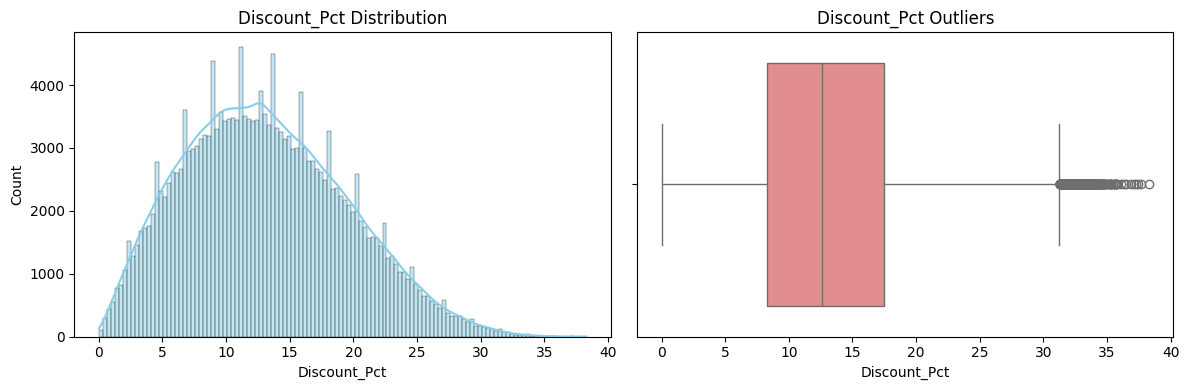

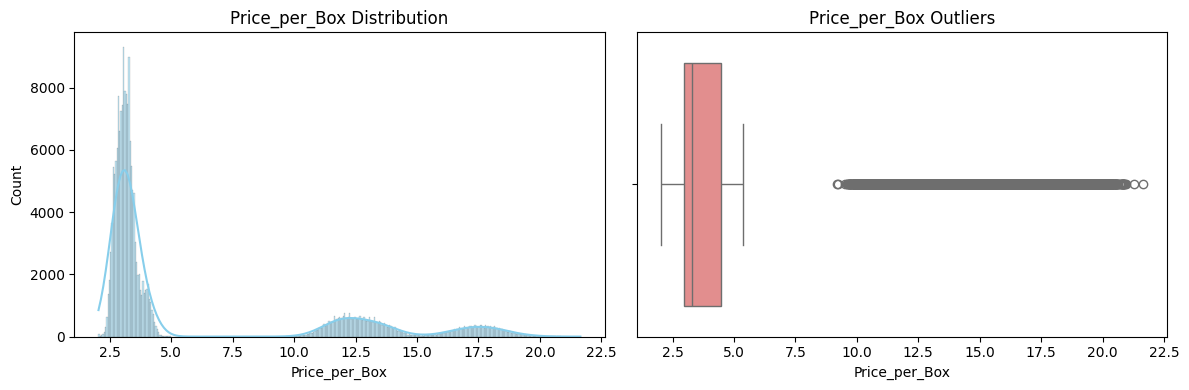

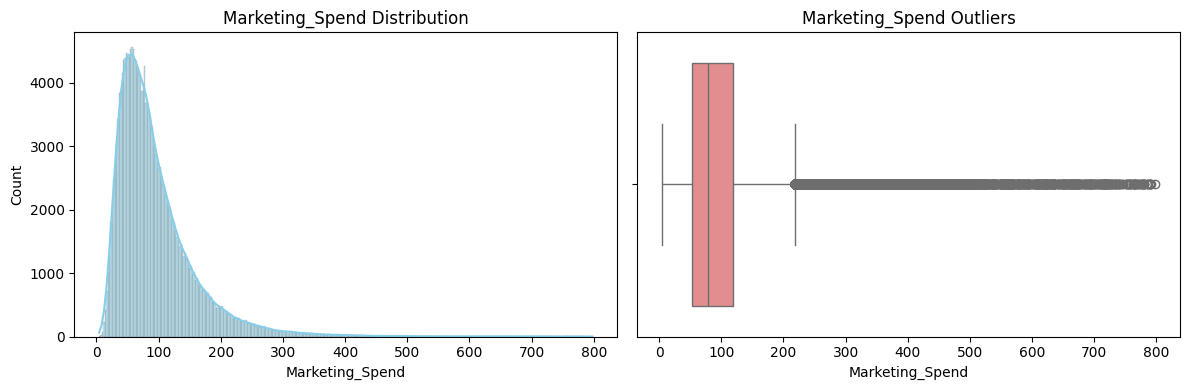

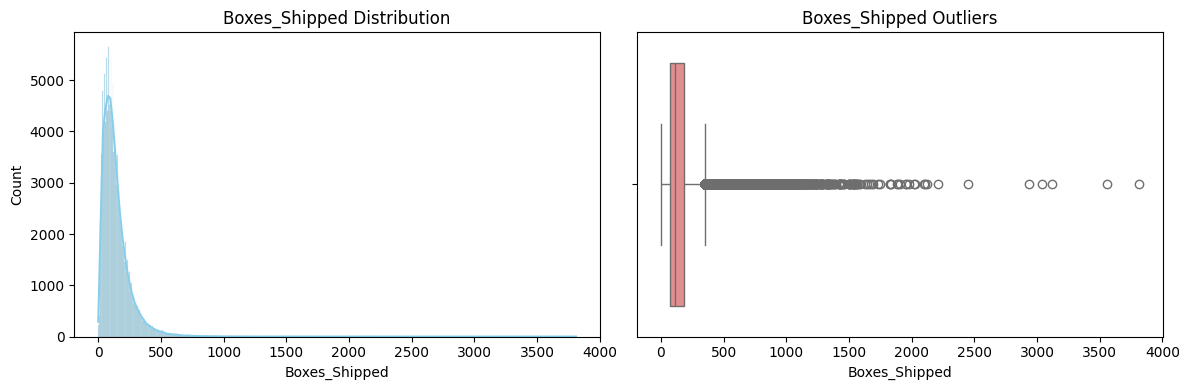

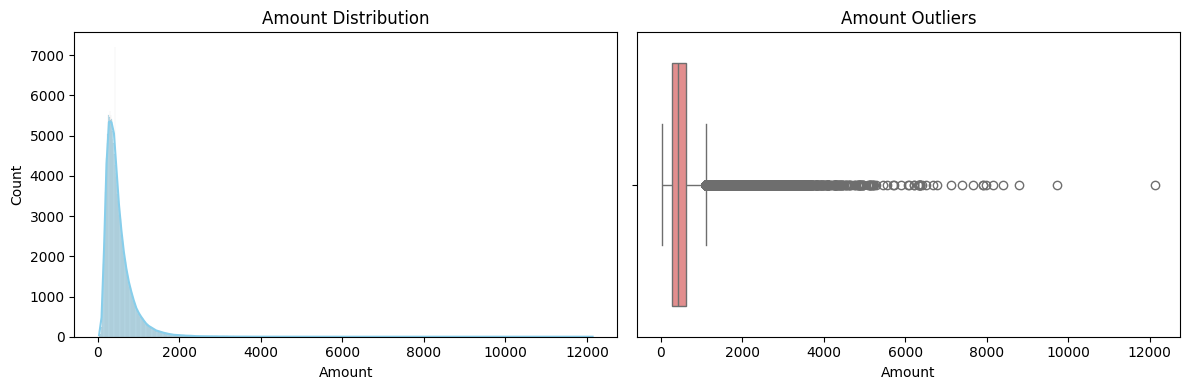

In [22]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

Above Graphs and Box Plots shows that most of our numerical data is left-skewed and it contains so many outliers

### 3.1.2 Categorical Columns (Count plots)

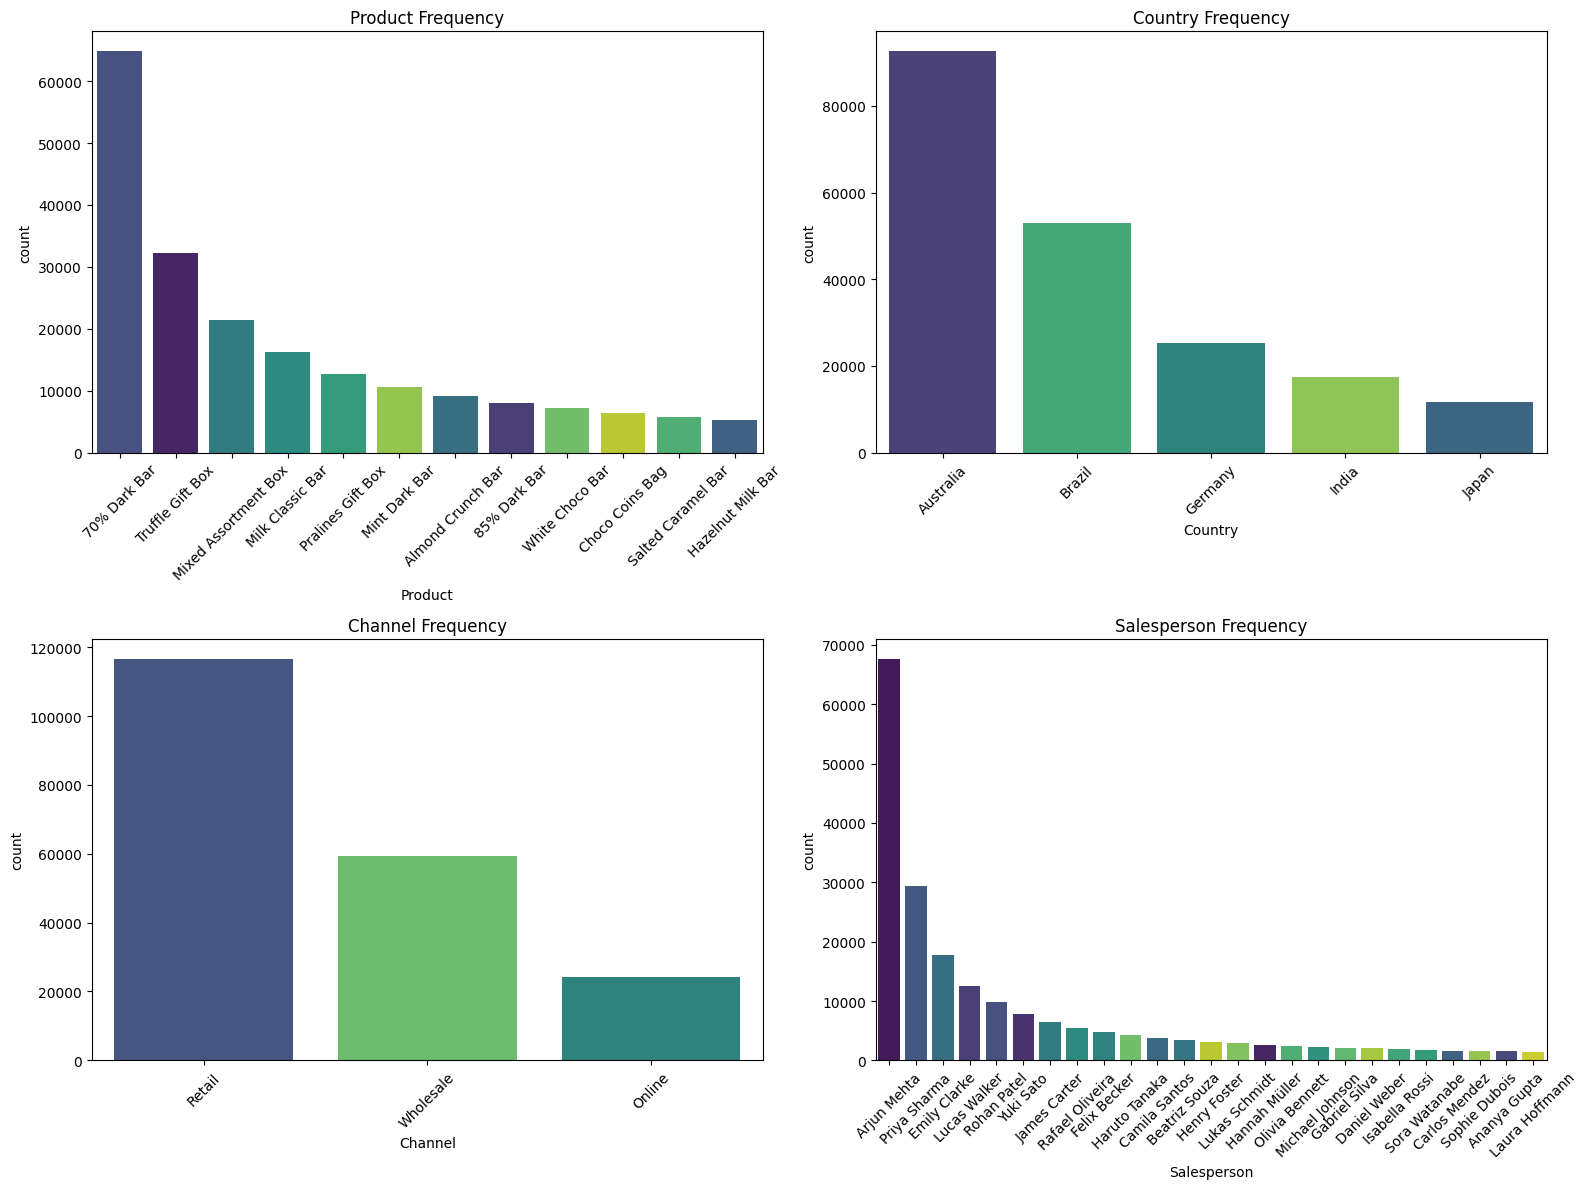

In [23]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2,2, i)
    
    sns.countplot(
        data=df, 
        x=col, 
        hue=col, 
        order=df[col].value_counts().index, 
        palette='viridis', 
        legend=False
    )
    
    plt.title(f'{col} Frequency')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**With the help of abve distribution we found**
* `70% Dark Bar` has the highest number of sales
* `Australia` is the topmost buyer of chocolates
* More than 50% of our sales done through `Retail`
* Top 5 Salesperson dominates almost 60% of the chocolate sales

## 3.2 Bivariate Analysis

### 3.2.1 Numerical vs. Numerical

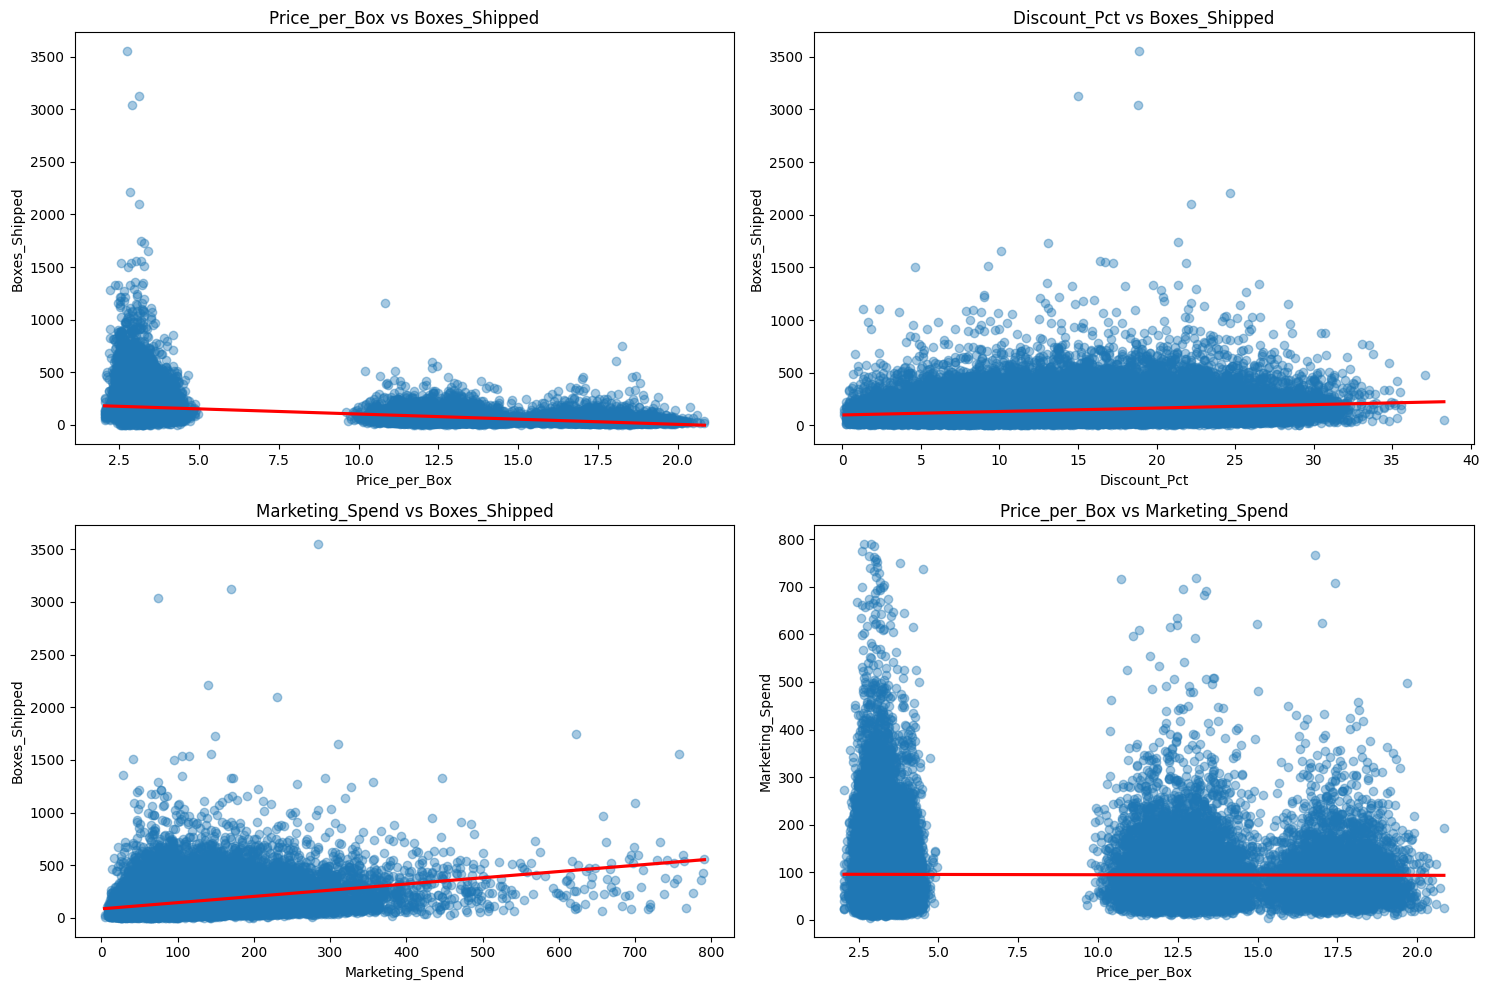

In [24]:
num_pairs = [
    ('Price_per_Box', 'Boxes_Shipped'),
    ('Discount_Pct', 'Boxes_Shipped'),
    ('Marketing_Spend', 'Boxes_Shipped'),
    ('Price_per_Box', 'Marketing_Spend')
]

# Since Dataset is so huge we're using a portion of it
sample_df = df.sample(50000, random_state=42)
plt.figure(figsize=(15, 10))

for i, (x, y) in enumerate(num_pairs, 1):
    plt.subplot(2, 2, i)
    
    sns.regplot(
        data=sample_df,
        x=x,
        y=y,
        scatter_kws={'alpha': 0.4},
        line_kws={'color': 'red'}
    )
    
    plt.title(f'{x} vs {y}')

plt.tight_layout()
plt.show()

### 3.2.2 Categorical vs. Categorical

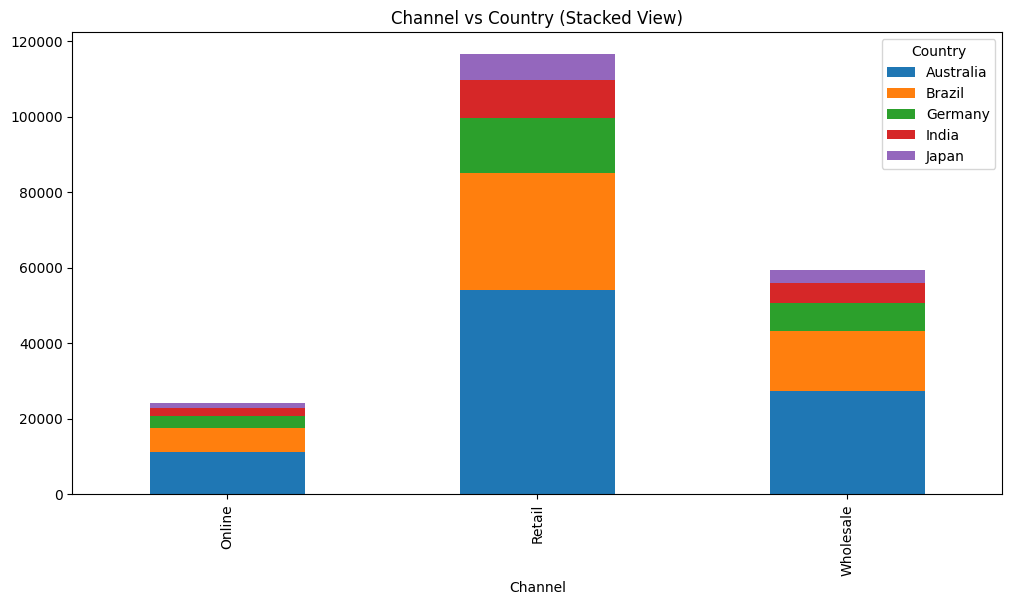

In [25]:
pd.crosstab(df['Channel'], df['Country']).plot(
    kind='bar',
    figsize=(12,6),
    stacked=True
)

plt.title("Channel vs Country (Stacked View)")
plt.show()

## 3.3 Multivariate

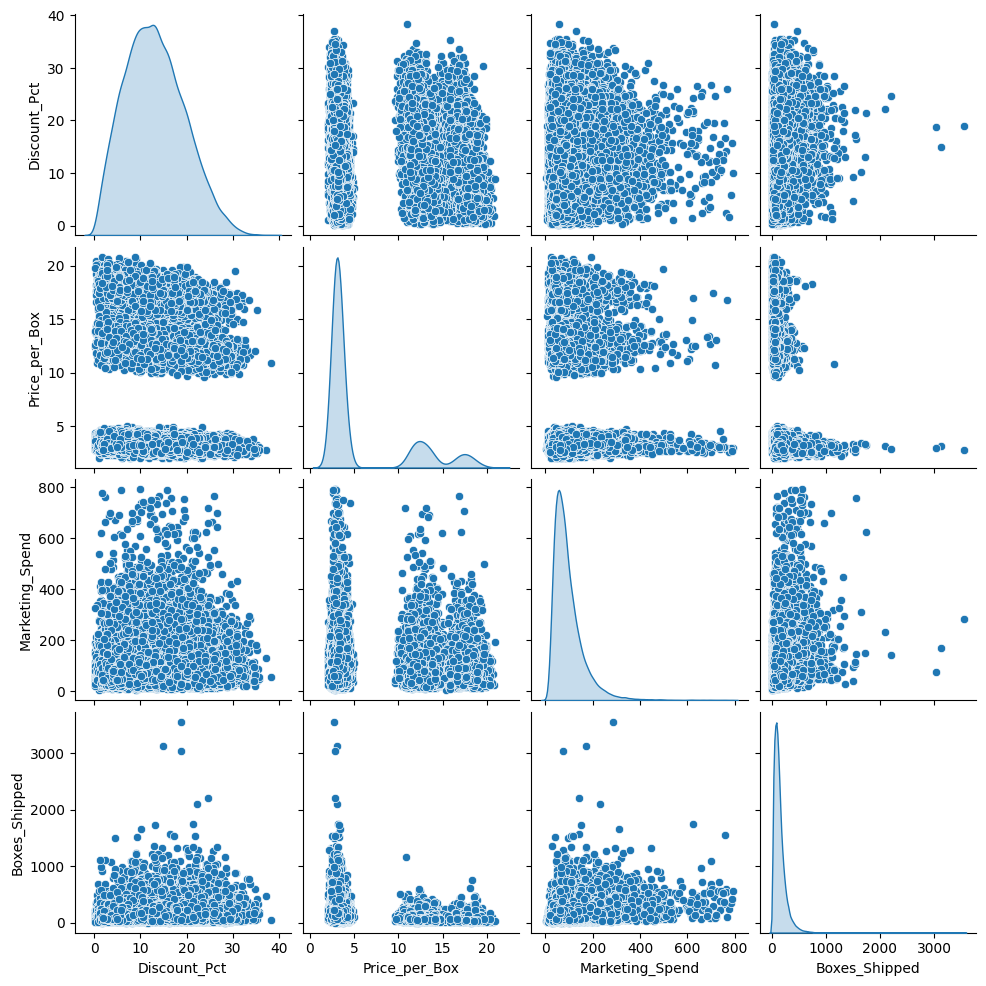

In [26]:
sns.pairplot(
    sample_df[['Discount_Pct', 'Price_per_Box', 'Marketing_Spend', 'Boxes_Shipped']],
    diag_kind='kde'
)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


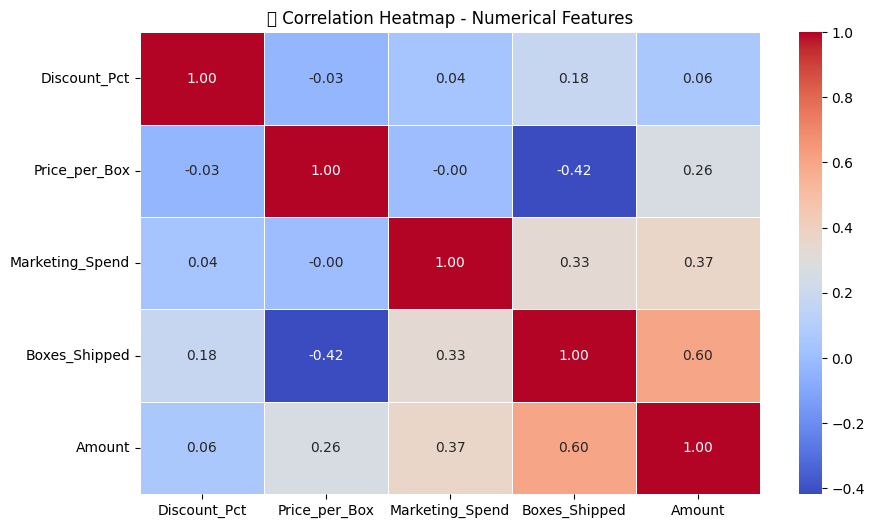

In [27]:
# ============================
# Correlation Heatmap (Multivariate Analysis)
# ============================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Correlation matrix of numerical features
corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("📊 Correlation Heatmap - Numerical Features")
plt.show()

# 4. Feature Engineering 

In [28]:
# Extract date features
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Quarter'] = df['Order_Date'].dt.quarter
df['Order_Day'] = df['Order_Date'].dt.day
df['Order_Weekday'] = df['Order_Date'].dt.weekday

# Revenue efficiency features
df['Discounted_Price'] = df['Price_per_Box'] * (1 - df['Discount_Pct']/100)

# Spend efficiency
df['Spend_per_Box'] = df['Marketing_Spend'] / (df['Boxes_Shipped'] + 1)

# Profit proxy feature
df['Revenue_Estimate'] = df['Price_per_Box'] * df['Boxes_Shipped']

In [29]:
# Dropping Date data because all the relevant feaures has been extracted
df = df.drop(columns=['Order_Date'])

# 5. Feature Transformation

In [30]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

## 5.1 Log Transformation

In [31]:
from scipy import stats
z_scores = np.abs(stats.zscore(df[num_cols]))

outliers = (z_scores > 3).sum()
print(outliers)

10264


In [32]:
skew_cols = [
    'Marketing_Spend',
    'Boxes_Shipped',
    'Amount',
    'Spend_per_Box'
]

for col in skew_cols:
    df[col] = np.log1p(df[col])   # log(1 + x) to avoid log(0)

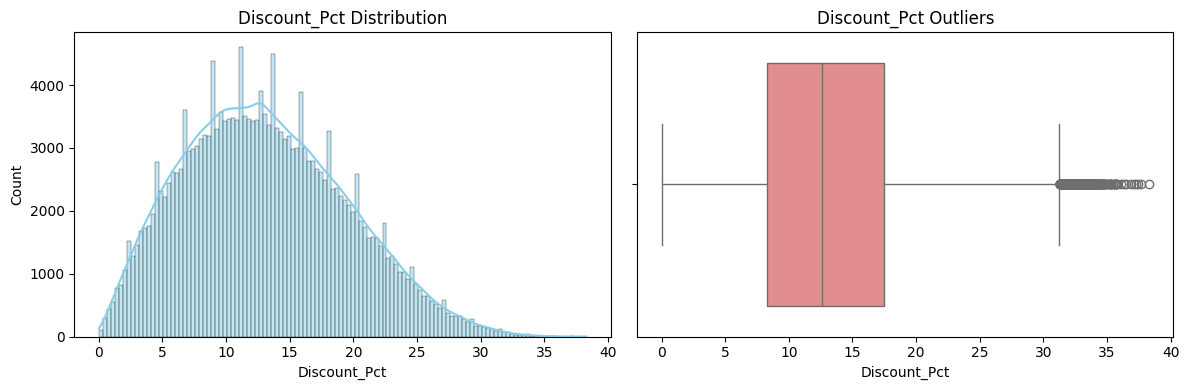

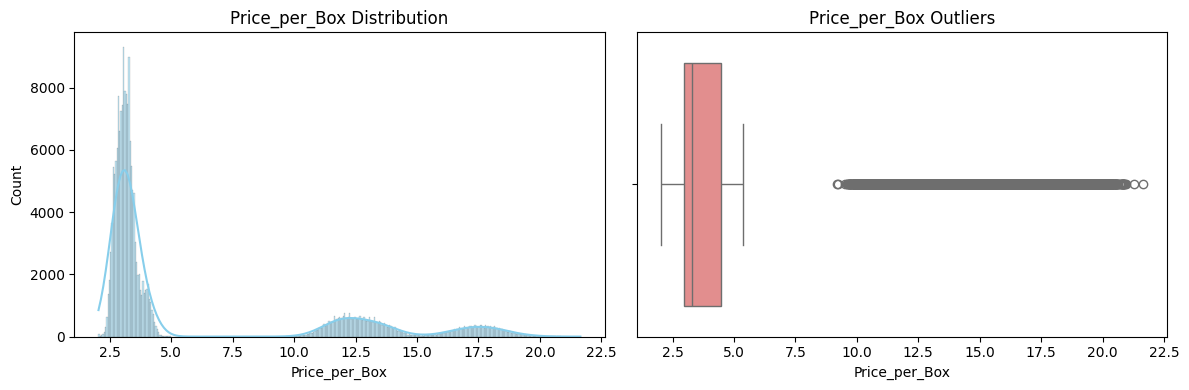

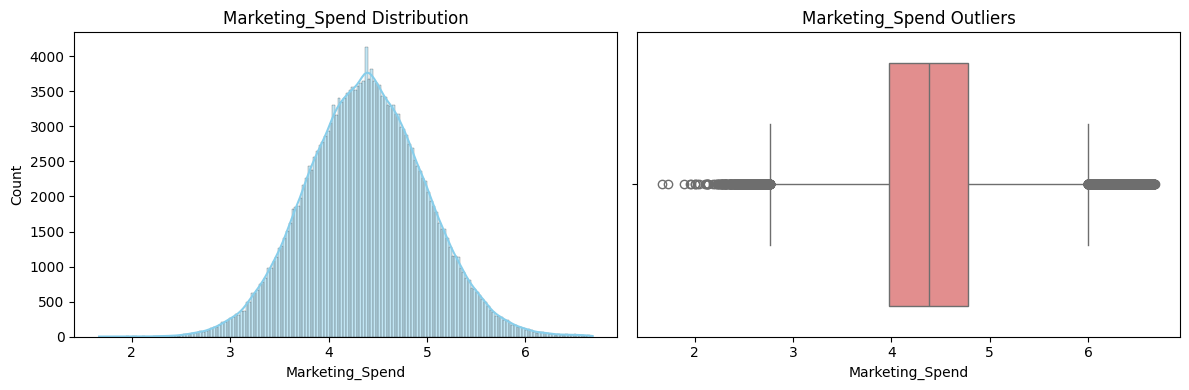

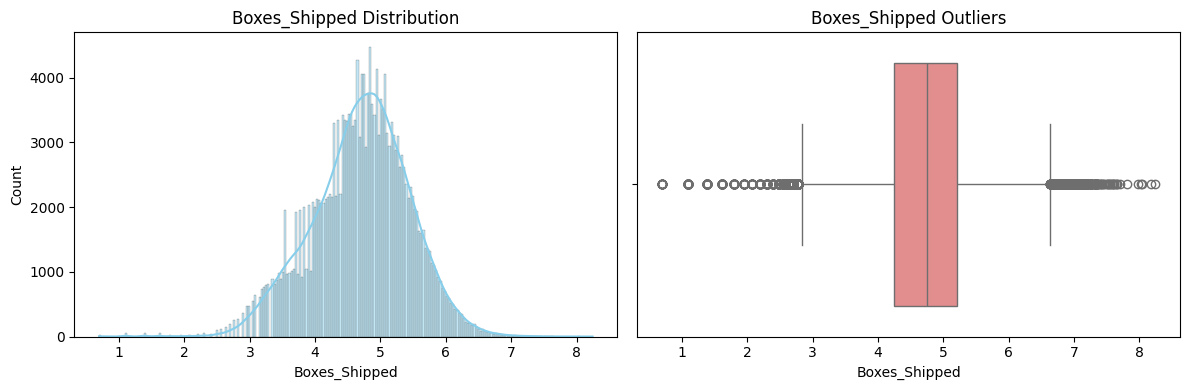

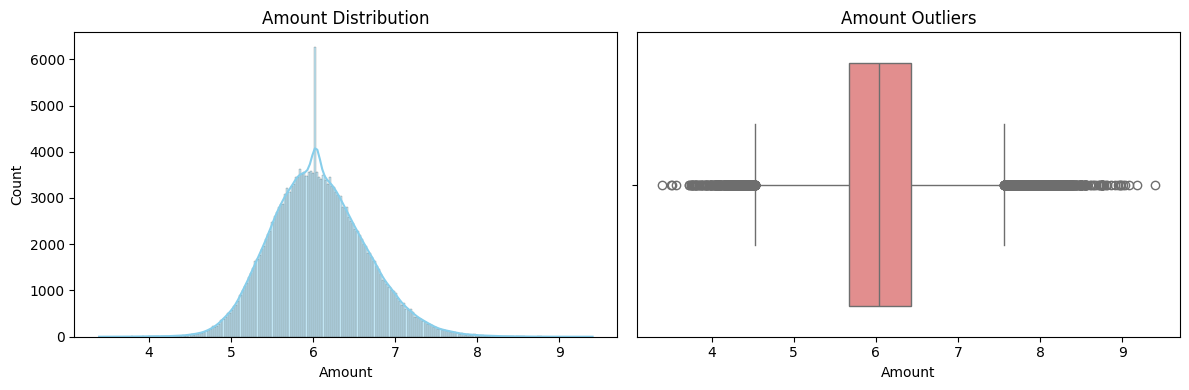

In [33]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

As you can see applying log transformation has remove skenwss from our dataset

In [34]:
z_scores = np.abs(stats.zscore(df[num_cols]))

outliers = (z_scores > 3).sum()
print(outliers)

2535


## 5.2 One-Hot Encoding

In [35]:
# Implementing OneHotEncoding -> Converting Categorical to numeric
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
df = pd.get_dummies(data=df,columns=cat_cols,drop_first = True,dtype=int)
df.head()

,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount,Order_Year,Order_Month,Order_Quarter,Order_Day,Order_Weekday,...,Salesperson_Lucas Walker,Salesperson_Lukas Schmidt,Salesperson_Michael Johnson,Salesperson_Olivia Bennett,Salesperson_Priya Sharma,Salesperson_Rafael Oliveira,Salesperson_Rohan Patel,Salesperson_Sophie Dubois,Salesperson_Sora Watanabe,Salesperson_Yuki Sato
0,3.5,13.72,5.313354,4.276666,6.817075,2022,12,4,11,6,...,0,0,0,0,0,0,0,0,0,0
1,9.4,3.30,4.028561,4.442651,5.509024,2023,3,1,14,1,...,0,0,0,0,0,0,0,0,0,0
2,4.9,18.21,4.121473,3.583519,6.371099,2023,12,4,21,3,...,0,0,0,0,0,0,0,0,0,0
3,15.0,2.66,3.970292,4.532599,5.357859,2023,12,4,18,0,...,0,0,0,0,0,0,0,0,0,0
4,4.4,2.75,5.238780,5.370638,6.311172,2023,8,3,18,4,...,0,0,0,0,0,0,0,0,0,1


### Splitting Data before Feature scaling

In [36]:
X = df.drop('Boxes_Shipped', axis=1)
y = df['Boxes_Shipped']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 5.3 Standard Scaling

In [38]:
scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=['int64','float64']).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [39]:
X_train_df = pd.DataFrame(X_train)
X_train_df.head()

,Discount_Pct,Price_per_Box,Marketing_Spend,Amount,Order_Year,Order_Month,Order_Quarter,Order_Day,Order_Weekday,Discounted_Price,...,Salesperson_Lucas Walker,Salesperson_Lukas Schmidt,Salesperson_Michael Johnson,Salesperson_Olivia Bennett,Salesperson_Priya Sharma,Salesperson_Rafael Oliveira,Salesperson_Rohan Patel,Salesperson_Sophie Dubois,Salesperson_Sora Watanabe,Salesperson_Yuki Sato
153248,-1.540180,-0.417501,-1.054001,-2.150144,2022,7,3,23,5,-0.328137,...,-0.257551,-0.121033,-0.109245,-0.109216,-0.414799,-0.168258,-0.225908,-0.088125,-0.094527,-0.202558
67802,-1.115861,1.653831,0.140809,-0.490141,2023,11,4,1,2,1.860444,...,-0.257551,-0.121033,-0.109245,-0.109216,-0.414799,-0.168258,-0.225908,-0.088125,-0.094527,-0.202558
148889,1.477206,-0.570932,1.754894,0.625814,2023,7,3,8,5,-0.632377,...,3.882725,-0.121033,-0.109245,-0.109216,-0.414799,-0.168258,-0.225908,-0.088125,-0.094527,-0.202558
103093,-0.942989,-0.451821,-0.507879,-1.108717,2022,8,3,11,3,-0.397838,...,-0.257551,-0.121033,-0.109245,-0.109216,-0.414799,-0.168258,-0.225908,-0.088125,-0.094527,-0.202558
104681,-0.424376,1.532701,-2.107009,-0.761971,2022,2,1,28,0,1.594806,...,-0.257551,-0.121033,-0.109245,-0.109216,-0.414799,-0.168258,-0.225908,11.347458,-0.094527,-0.202558


# 6. Machine Learning and Hyperparameter Tuning

In [40]:
from sklearn.model_selection import RandomizedSearchCV,KFold, cross_val_score

# Linear Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet

# Tree-Based Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Boosting Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [41]:
models = {

    # ============================
    # Linear Models (Baseline)
    # ============================
    "Linear Regression": LinearRegression(
        n_jobs=-1  # if supported by your sklearn version
    ),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "ElasticNet": ElasticNet(),

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    # ============================
    # Boosting Models (CPU)
    # ============================
    "XGBoost": XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        tree_method='hist',   # CPU-optimized
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        force_col_wise=True,
        verbose=-1,
        n_jobs=1
    )
}

In [42]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [43]:
param_grids = {
    "Linear Regression": {},

    "Ridge Regression": {
        "alpha": [0.1, 1.0, 10, 50, 100]
    },

    "Lasso Regression": {
        "alpha": [0.001, 0.01, 0.1, 1, 10]
    },

    "ElasticNet": {
        "alpha": [0.001, 0.01, 0.1, 1],
        "l1_ratio": [0.2, 0.5, 0.8]
    },

    "Decision Tree": {
        "max_depth": [3, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 5]
    },


    "XGBoost": {
        "n_estimators": [100, 300, 500],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8, 1],
        "colsample_bytree": [0.7, 0.8, 1]
    },

    "LightGBM": {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 50],
    "max_depth": [3, 5, 7, 10],
    "min_child_samples": [10, 20]
    }
}

In [44]:
best_model = None
best_score = -float("inf")
best_model_name = ""

results = {}

for name, model in models.items():

    print(f"\nRunning GridSearchCV for {name}...")

    random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grids[name],
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    n_iter=10,
    random_state=42
    )

    random_search.fit(X_train, y_train)

    results[name] = {
        "Best Params": random_search.best_params_,
        "Best CV Score (R2)": random_search.best_score_
    }

    print(name)
    print("Best Params:", random_search.best_params_)
    print("Best CV Score (R2):", random_search.best_score_)

    # STORE ONLY BEST MODEL
    if random_search.best_score_ > best_score:
        best_score = random_search.best_score_
        best_model = random_search.best_estimator_
        best_model_name = name


Running GridSearchCV for Linear Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Linear Regression
Best Params: {}
Best CV Score (R2): 0.9698028130102638

Running GridSearchCV for Ridge Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Ridge Regression
Best Params: {'alpha': 0.1}
Best CV Score (R2): 0.9698028143691927

Running GridSearchCV for Lasso Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Lasso Regression
Best Params: {'alpha': 0.001}
Best CV Score (R2): 0.9687678792285677

Running GridSearchCV for ElasticNet...
ElasticNet
Best Params: {'l1_ratio': 0.2, 'alpha': 0.001}
Best CV Score (R2): 0.9695160377314129

Running GridSearchCV for Decision Tree...
Decision Tree
Best Params: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 15}
Best CV Score (R2): 0.9996973603378498

Running GridSearchCV for XGBoost...
XGBoost
Best Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1}
Best CV Score (R2): 0.9991978662389863

Running GridSearchCV for LightGBM...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


LightGBM
Best Params: {'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 10, 'learning_rate': 0.1}
Best CV Score (R2): 0.9991046361447669


In [45]:
# DataFram of results to make it more readable
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Best CV Score (R2)", ascending=False)

,Best Params,Best CV Score (R2)
Decision Tree,"{'min_samples_split': 2, 'min_samples_leaf': 2...",0.999697
XGBoost,"{'subsample': 0.8, 'n_estimators': 300, 'max_d...",0.999198
LightGBM,"{'num_leaves': 31, 'n_estimators': 300, 'min_c...",0.999105
Ridge Regression,{'alpha': 0.1},0.969803
Linear Regression,{},0.969803
ElasticNet,"{'l1_ratio': 0.2, 'alpha': 0.001}",0.969516
Lasso Regression,{'alpha': 0.001},0.968768


In [46]:
print("Best Model:", best_model_name)
print("Best CV Score (R2):", best_score)

Best Model: Decision Tree
Best CV Score (R2): 0.9996973603378498


In [47]:
y_pred = best_model.predict(X_test)

In [48]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.0039235667031091645
RMSE: 0.011009627393221413
R2 Score: 0.9997803616150935


Please upvotte me if you like my work :)